# 🧠 Patrón 9: Agentic RAG — Sistema Q&A Médico con LangGraph

### ¿Qué es?
**Agentic RAG** convierte el proceso de recuperación de información en un ciclo agéntico activo. El LLM actúa como **decision-maker**: enruta a la fuente más adecuada, evalúa la relevancia de los documentos recuperados, reformula queries si los resultados no son buenos, y verifica alucinaciones.


### Diagrama del Grafo

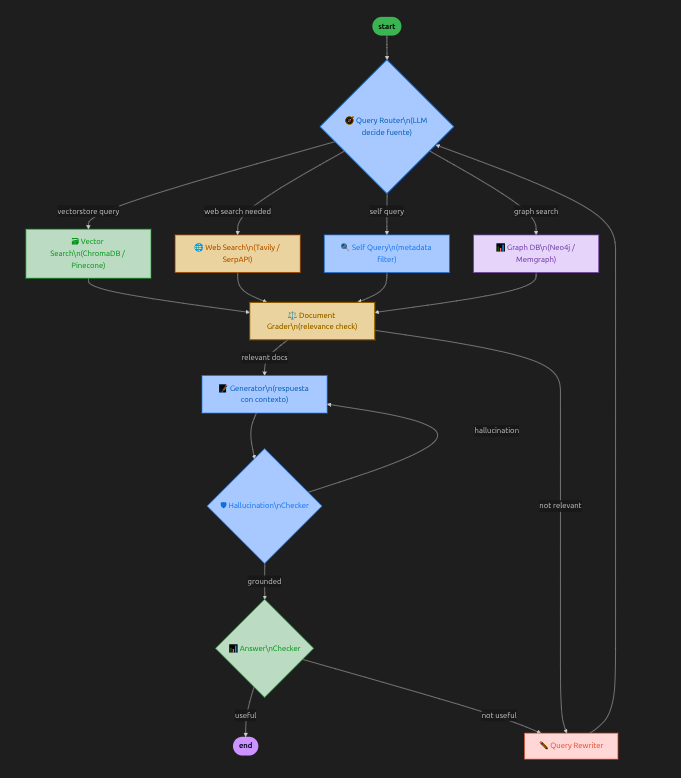

Dataset: MedQuAD — Medical Question-Answer Dataset (Kaggle)

* 47,457 pares Q&A creados desde 12 sitios web del NIH (National Institutes of Health)
* Columnas: qtype, Question, Answer, focus_area
* Licencia: CC BY-SA 4.0 — libre para uso en investigación

Caso de uso real: Agente que responde preguntas médicas enrutando dinámicamente entre una base vectorial interna (ChromaDB con MedQuAD) y búsqueda web, evalúa la relevancia de los documentos recuperados, reformula si es necesario, y verifica alucinaciones antes de responder.

Dependencias:
```bash
!pip install -q \
    langgraph \
    langchain \
    langchain-anthropic \
    langchain-community \
    langchain-chroma \
    chromadb \
    sentence-transformers \
    kaggle \
    pandas \
    langchain-huggingface \
    python-dotenv --quiet
```

Diagrama del caso de uso:

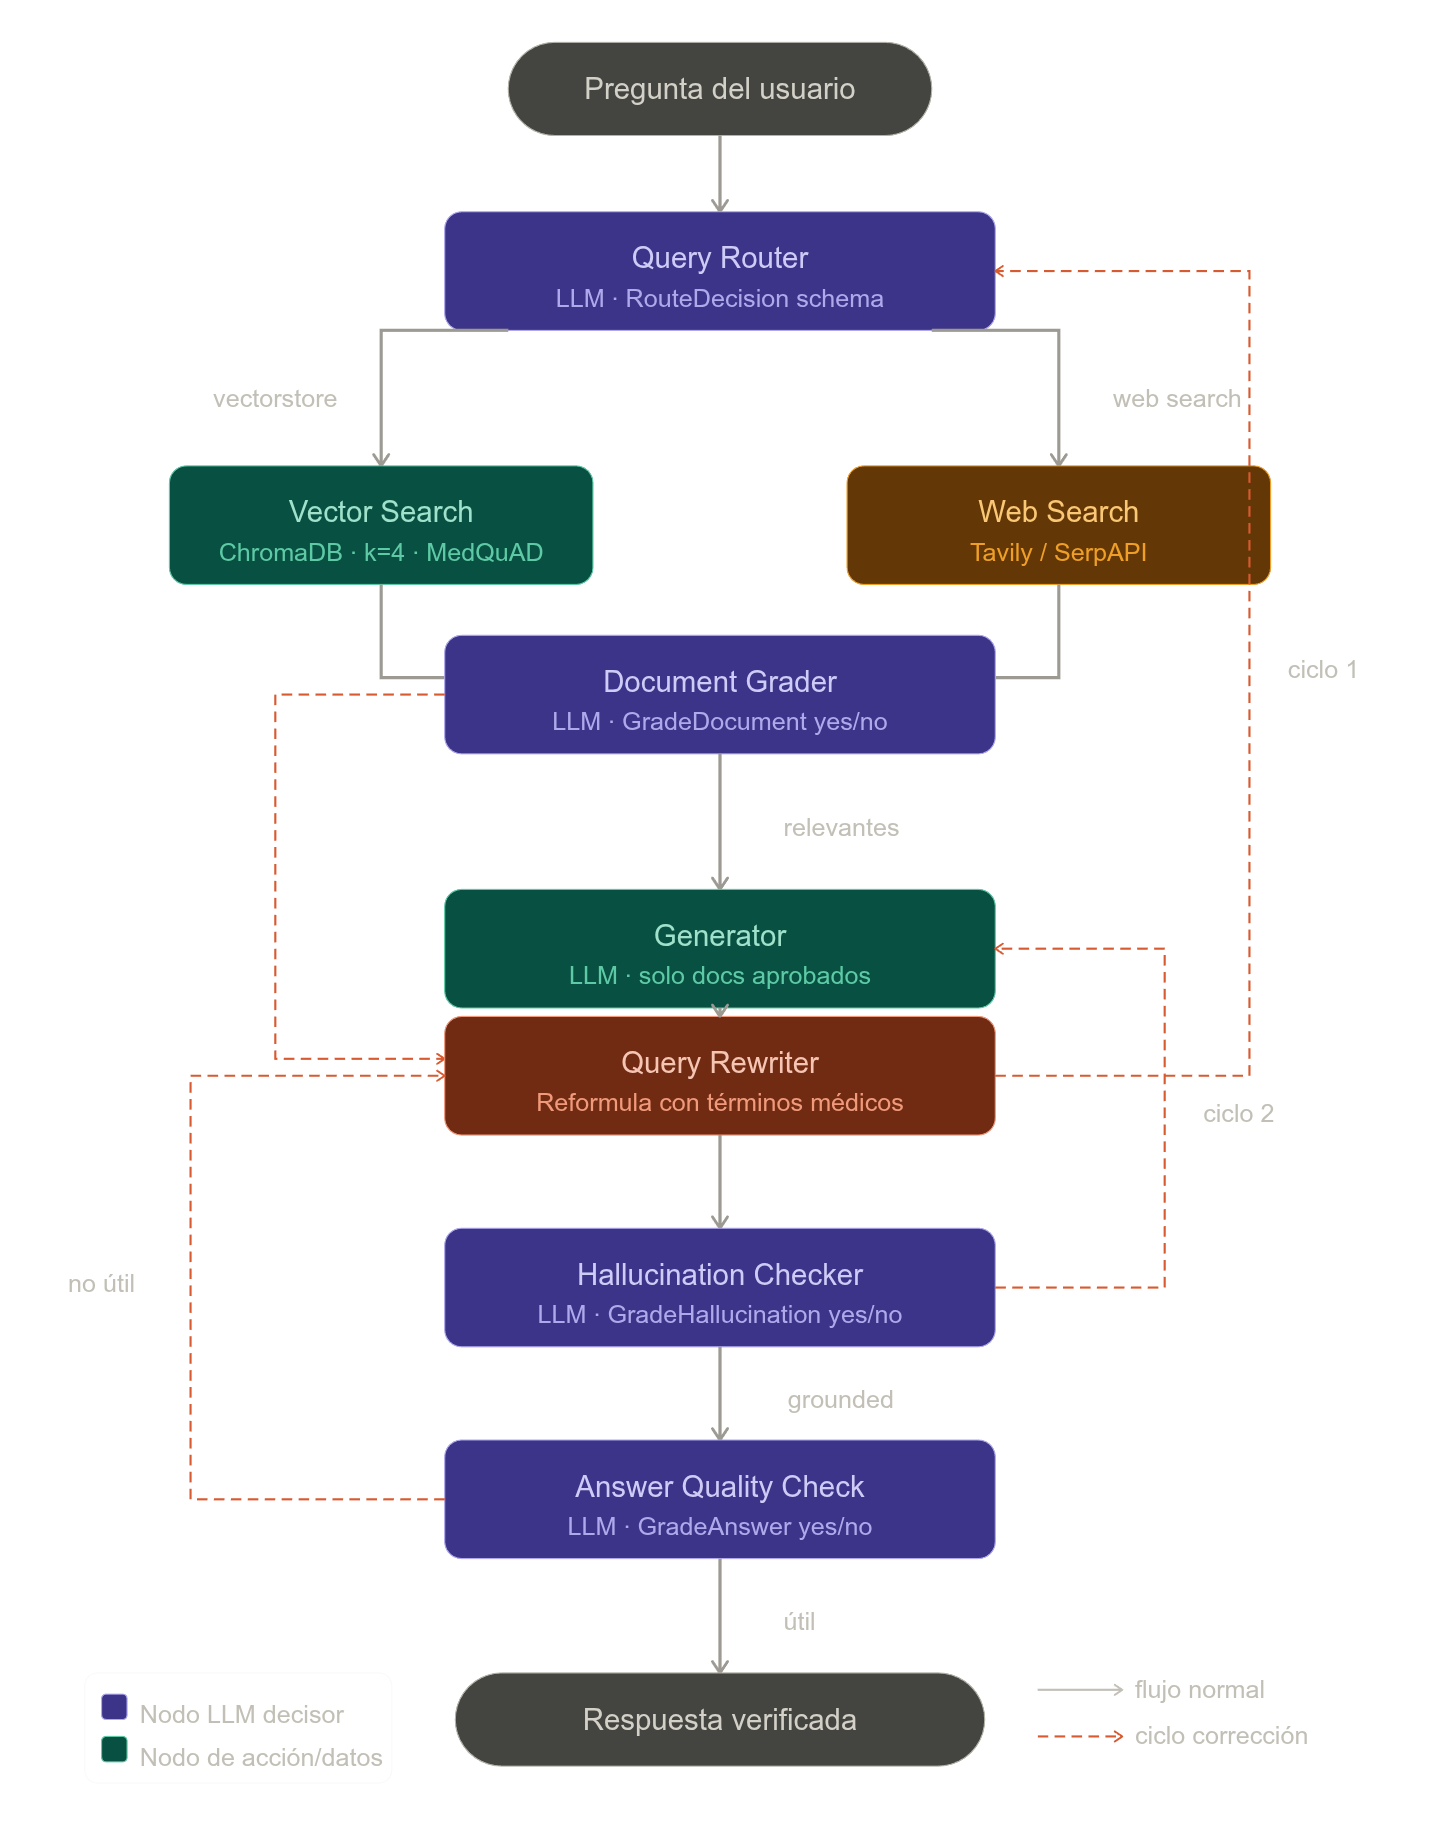


Nodos:
|Nodo|Patrón del diagrama|Qué hace|
|:---|:------------------|:-------|
|route|Query Router|Decide: VectorStore (MedQuAD) vs Web Search|
|retrieve|Vector Search|Recupera 4 docs de ChromaDB con embeddings|
|web_search|Web Search|Fallback para preguntas fuera del vectorstore|
|grade_docs|Document Grader|Filtra docs irrelevantes con LLM|
|rewrite|Query Rewriter|Reformula la pregunta si los docs fueron malos|
|generate|Generator|Responde basado SOLO en docs aprobados|
|halluc_check|Hallucination Checker|Verifica que la respuesta sea fiel a los docs|
|answer_check|Answer Checker|Verifica que la respuesta resuelva la pregunta|

|Nodo/Componente|Tipo|Función|Descripción|
|:--------------|:---|:------|:----------|
|Pregunta del usuario|Entrada (START)|Punto de entrada al grafo|Texto libre en lenguaje natural. Inicializa el RAGState con la pregunta y todos los campos vacíos.|
|Query Router|Nodo LLM decisor|Clasificar la fuente de datos|LLM con with_structured_output(RouteDecision). Analiza la pregunta y retorna "vectorstore" (preguntas médicas clínicas) o "web_search" (guidelines recientes, off-topic).|
|Vector Search|Nodo de recuperación|Buscar documentos por similitud semántica|Consulta ChromaDB con embeddings all-MiniLM-L6-v2. Recupera k=4 documentos del dataset MedQuAD (NIH). Retorna pares Q&A como contexto.|
|Web Search|Nodo de recuperación|Buscar en la web en tiempo real|Fallback externo via Tavily o SerpAPI. Se activa cuando el Router decide que el vectorstore no tiene la respuesta o cuando el Grader descarta >50% de los docs internos.|
|Document Grader|Nodo LLM decisor|Filtrar documentos irrelevantes|LLM con with_structured_output(GradeDocument). Evalúa cada documento individualmente (yes/no). Documentos irrelevantes se descartan. Si quedan 0 docs relevantes activa el ciclo de recuperación.|
|Query Rewriter|Nodo de corrección|Reformular la pregunta fallida|Se activa cuando el Grader no aprueba documentos. Reformula la pregunta con terminología médica más precisa e incrementa el contador iterations. Redirige al Router — ciclo 1.|
|Generator|Nodo LLM generador|Producir la respuesta médica|LLM que genera la respuesta usando SOLO los documentos aprobados por el Grader (máx. 3). El system prompt prohíbe explícitamente inventar información médica.|
|Hallucination Checker|Nodo LLM evaluador|Detectar información no fundamentada|LLM con with_structured_output(GradeHallucination). Compara la respuesta generada contra los documentos de referencia. Si detecta contradicciones o datos inventados → regresa al Generator — ciclo 2.|
|Answer Quality Check|Nodo LLM evaluador|Verificar que la respuesta es útil|LLM con with_structured_output(GradeAnswer). Evalúa si la respuesta resuelve la pregunta original (no solo si es factualmente correcta). Si falla → activa el Rewriter para reformular desde cero.|
|Respuesta verificada|Salida (END)|Entregar resultado al usuario|Respuesta que pasó los tres filtros: relevancia de docs (Grader), ausencia de alucinaciones (Hallucination Checker) y utilidad para el usuario (Answer Quality Check).|
|MAX_ITERATIONS = 3|Parámetro de control|Evitar loops infinitos|Contador compartido en el RAGState. Cuando se alcanza el límite, cualquier edge condicional fuerza la salida hacia answer_check o END independientemente del resultado del evaluador.|
|RAGState|Estado del grafo|Compartir datos entre todos los nodos|TypedDict con campos: question, datasource, documents, graded_docs, generation, web_search_needed, hallucination_ok, answer_useful, iterations. Fluye por todos los nodos.|
|ChromaDB|Componente de infraestructura|Almacenar y recuperar embeddings|Vectorstore persistente en disco. Indexa 2,000 documentos MedQuAD en batches de 100. Búsqueda por similitud coseno con embeddings HuggingFace.|
|MedQuAD (NIH)|Fuente de datos|Base de conocimiento médico|47,457 pares Q&A extraídos de 12 sitios del NIH. Columnas: question, answer, focus_area, source. Licencia CC BY-SA 4.0. Disponible en Kaggle.|




### Cuándo usarlo
- ✅ Knowledge bases internas con datos que cambian frecuentemente
- ✅ Sistemas Q&A de alta precisión (legal, médico, compliance)
- ✅ Plataformas que combinan bases privadas + conocimiento web
- ✅ Sistemas donde las alucinaciones tienen costo alto
- ❌ Cuando la latencia es crítica (múltiples pasos de LLM añaden tiempo)

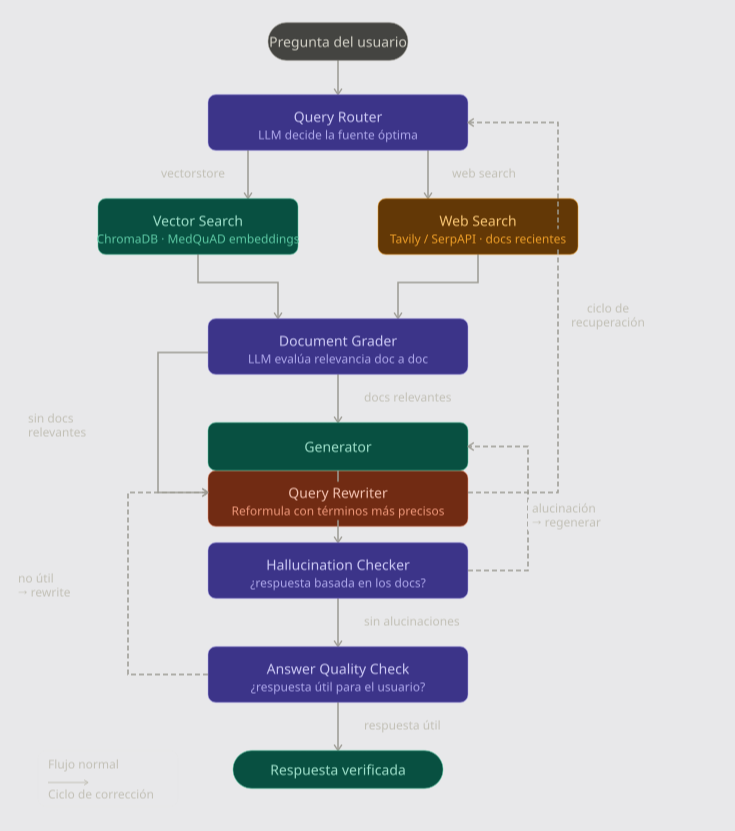
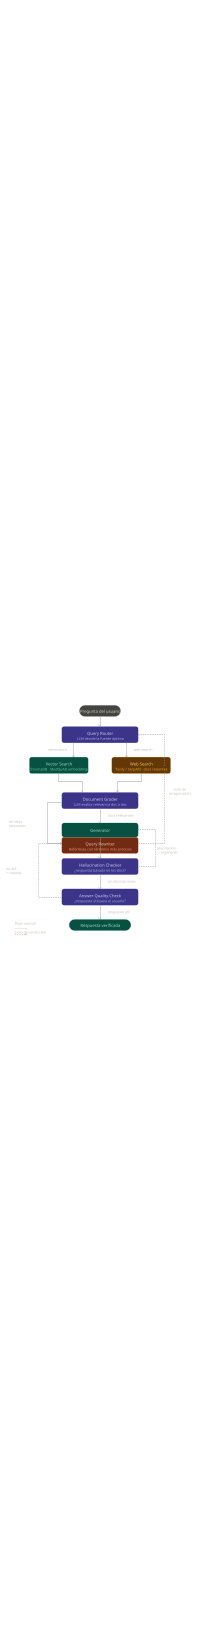

In [1]:
!pip install -q \
    langgraph \
    langchain \
    langchain-anthropic \
    langchain-community \
    langchain-chroma \
    chromadb \
    sentence-transformers \
    kaggle \
    pandas \
    langchain-huggingface \
    python-dotenv --quiet

error: externally-managed-environment

× This environment is externally managed
╰─> To install Python packages system-wide, try apt install
    python3-xyz, where xyz is the package you are trying to
    install.
    
    If you wish to install a non-Debian-packaged Python package,
    create a virtual environment using python3 -m venv path/to/venv.
    Then use path/to/venv/bin/python and path/to/venv/bin/pip. Make
    sure you have python3-full installed.
    
    If you wish to install a non-Debian packaged Python application,
    it may be easiest to use pipx install xyz, which will manage a
    virtual environment for you. Make sure you have pipx installed.
    
    See /usr/share/doc/python3.14/README.venv for more information.

note: If you believe this is a mistake, please contact your Python installation or OS distribution provider. You can override this, at the risk of breaking your Python installation or OS, by passing --break-system-packages.
hint: See PEP 668 for the detai

In [2]:
import os
from dotenv import load_dotenv
import glob
import re
load_dotenv()
import json
import pandas as pd
from IPython.display import Image, display, Markdown
import matplotlib.pyplot as plt
import matplotlib

In [3]:
from langchain_community.vectorstores import Chroma
#from langchain_community.embeddings import HuggingFaceEmbeddings
from langchain_huggingface import HuggingFaceEmbeddings
from langchain_core.documents import Document
import chromadb

In [4]:
from typing import TypedDict, List, Literal, Optional
from pydantic import BaseModel, Field
from langchain_anthropic import ChatAnthropic
from langchain_core.messages import HumanMessage, SystemMessage
from langgraph.graph import StateGraph, START, END


### Descarga del dataset desde Kaggle

In [5]:
!kaggle datasets download -d pythonafroz/medquad-medical-question-answer-for-ai-research --unzip -p ./data/medquad

Dataset URL: https://www.kaggle.com/datasets/pythonafroz/medquad-medical-question-answer-for-ai-research
License(s): CC-BY-SA-4.0
100%|██████████████████████████████████████| 4.95M/4.95M [00:01<00:00, 4.63MB/s]



###  Exploración del dataset

In [6]:
# Listar archivos disponibles
files = glob.glob("./data/medquad/**/*.csv", recursive=True)
print(f"Archivos CSV encontrados: {len(files)}")
for f in files[:5]:
    print(" ", f)

# Cargar el CSV principal (el dataset tiene un archivo combinado)
# Si hay múltiples CSVs, los concatenamos
dfs = [pd.read_csv(f, encoding="utf-8", on_bad_lines="skip") for f in files]
df = pd.concat(dfs, ignore_index=True)

print(f"\nTotal de registros: {len(df):,}")
print(f"Columnas: {df.columns.tolist()}")
print(f"\nPrimeras filas:")
df.head(3)

Archivos CSV encontrados: 1
  ./data/medquad/medquad.csv

Total de registros: 16,412
Columnas: ['question', 'answer', 'source', 'focus_area']

Primeras filas:


,question,answer,source,focus_area
0,What is (are) Glaucoma ?,Glaucoma is a group of diseases that can damag...,NIHSeniorHealth,Glaucoma
1,What causes Glaucoma ?,"Nearly 2.7 million people have glaucoma, a lea...",NIHSeniorHealth,Glaucoma
2,What are the symptoms of Glaucoma ?,Symptoms of Glaucoma Glaucoma can develop in ...,NIHSeniorHealth,Glaucoma


### Limpieza y preparación

In [7]:
# Normalizar nombres de columnas (el CSV puede tener variaciones)
df.columns = [c.strip().lower().replace(" ", "_") for c in df.columns]

# Las columnas esperadas son: qtype, question, answer, focus_area
# Renombrar si es necesario
rename_map = {}
for col in df.columns:
    if "question" in col:
        rename_map[col] = "question"
    elif "answer" in col:
        rename_map[col] = "answer"
    elif "focus" in col or "topic" in col:
        rename_map[col] = "focus_area"
    elif "type" in col or "qtype" in col:
        rename_map[col] = "qtype"
df.rename(columns=rename_map, inplace=True)

# Limpiar valores nulos
df = df.dropna(subset=["question", "answer"])
df["question"] = df["question"].str.strip()
df["answer"] = df["answer"].str.strip()
df["focus_area"] = df.get("focus_area", pd.Series(["General"] * len(df))).fillna("General")

# Filtrar respuestas muy cortas (menos de 50 caracteres)
df = df[df["answer"].str.len() >= 50]

# Tomar una muestra representativa para el demo (2000 registros)
df_sample = df.sample(n=min(2000, len(df)), random_state=42).reset_index(drop=True)

print(f"Registros después de limpieza: {len(df_sample):,}")
print(f"\nDistribución por tipo de pregunta:")
if "qtype" in df_sample.columns:
    print(df_sample["qtype"].value_counts().head(10))
print(f"\nEjemplo de registro:")
print(f"Pregunta: {df_sample['question'][0]}")
print(f"Respuesta (primeros 200 chars): {df_sample['answer'][0][:200]}...")
print(f"Focus area: {df_sample['focus_area'][0]}")

Registros después de limpieza: 2,000

Distribución por tipo de pregunta:

Ejemplo de registro:
Pregunta: Do you have information about Nutritional Support
Respuesta (primeros 200 chars): Summary : Nutritional support is therapy for people who cannot get enough nourishment by eating or drinking. You may need it if you        - Can't swallow    - Have problems with your appetite    - Ar...
Focus area: Nutritional Support


### Construcción del VectorStore (ChromaDB)

In [8]:
# Modelo de embeddings liviano (sin costo de API)
# all-MiniLM-L6-v2: 80MB, excelente para inglés, rápido en CPU
import warnings
warnings.filterwarnings("ignore")
hf_token = os.environ.get("HUGGINGFACEHUB_API_TOKEN")

embeddings = HuggingFaceEmbeddings(
    model_name="sentence-transformers/all-MiniLM-L6-v2",
    model_kwargs={"device": "cpu"},
    encode_kwargs={"normalize_embeddings": True},
)

print("✅ Embeddings cargados")

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

✅ Embeddings cargados


In [9]:
# Construir documentos LangChain desde el DataFrame
print(f"\n📄 Construyendo {len(df_sample)} documentos...")

documents = []
for _, row in df_sample.iterrows():
    # Combinamos pregunta + respuesta como contenido del documento
    # Esto permite recuperar por similitud semántica con la query del usuario
    content = f"Q: {row['question']}\n\nA: {row['answer']}"
    doc = Document(
        page_content=content,
        metadata={
            "question":   row["question"],
            "focus_area": str(row.get("focus_area", "General")),
            "qtype":      str(row.get("qtype", "general")),
            "source":     "MedQuAD-NIH",
        },
    )
    documents.append(doc)

print(f"✅ {len(documents)} documentos listos")


📄 Construyendo 2000 documentos...
✅ 2000 documentos listos


In [10]:
# Crear (o cargar si ya existe) el vectorstore en disco
CHROMA_PATH = "./chroma_medquad"

if os.path.exists(CHROMA_PATH):
    print(f"\n♻️  Cargando vectorstore existente desde {CHROMA_PATH}...")
    vectorstore = Chroma(
        persist_directory=CHROMA_PATH,
        embedding_function=embeddings,
        collection_name="medquad",
    )
    print(f"✅ Vectorstore cargado ({vectorstore._collection.count()} documentos)")
else:
    print(f"\n🔨 Creando vectorstore en {CHROMA_PATH}...")
    print("   (Puede tomar 2-5 minutos para 2000 documentos en CPU)")

    # Procesamos en batches para evitar OOM
    BATCH_SIZE = 100
    vectorstore = None

    for i in range(0, len(documents), BATCH_SIZE):
        batch = documents[i : i + BATCH_SIZE]
        if vectorstore is None:
            vectorstore = Chroma.from_documents(
                documents=batch,
                embedding=embeddings,
                collection_name="medquad",
                persist_directory=CHROMA_PATH,
            )
        else:
            vectorstore.add_documents(batch)

        if (i // BATCH_SIZE) % 5 == 0:
            print(f"   Procesados {min(i + BATCH_SIZE, len(documents))}/{len(documents)} documentos...")

    vectorstore.persist()
    print(f"✅ Vectorstore creado y guardado en {CHROMA_PATH}")

retriever = vectorstore.as_retriever(search_kwargs={"k": 4})


♻️  Cargando vectorstore existente desde ./chroma_medquad...
✅ Vectorstore cargado (2000 documentos)


### Definición del State y LLM

In [ ]:
# ── Patch compatibilidad: langchain-core vs paquete `langchain` ───────────────
# langchain-core consulta globals (verbose/debug/llm_cache) en el módulo `langchain`.
# Si esa versión no los expone -> AttributeError ("module 'langchain' has no
# attribute 'verbose'"). Ejecuta esta celda ANTES de instanciar ChatAnthropic.
import langchain
import langchain_core.globals as _lcg
for _attr, _default in (("verbose", False), ("debug", False), ("llm_cache", None)):
    if not hasattr(langchain, _attr):
        setattr(langchain, _attr, _default)
for _name, _fb in (("get_verbose", False), ("get_llm_cache", None)):
    _orig = getattr(_lcg, _name, None)
    if _orig is not None:
        def _make(orig, fb):
            def _patched():
                try:
                    return orig()
                except AttributeError:
                    return fb
            return _patched
        setattr(_lcg, _name, _make(_orig, _fb))
print("✅ patch compatibilidad langchain aplicado")


In [11]:
# ── LLM ──────────────────────────────────────────────────────────────
llm = ChatAnthropic(
    model="claude-haiku-4-5",   # Haiku: rápido y económico para los nodos de grading
    temperature=0,
)

In [12]:
# ── State ─────────────────────────────────────────────────────────────
class RAGState(TypedDict):
    question:         str
    datasource:       str                # "vectorstore" | "web_search"
    documents:        List[str]          # textos recuperados
    generation:       str                # respuesta generada
    graded_docs:      List[str]          # documentos relevantes tras grading
    web_search_needed: bool              # ¿algún doc fue descartado?
    hallucination_ok: bool               # ¿la respuesta está basada en docs?
    answer_useful:    bool               # ¿la respuesta resuelve la pregunta?
    iterations:       int                # contador de ciclos (anti-loop)


In [13]:
# ── Schemas Pydantic para structured output ───────────────────────────
class RouteDecision(BaseModel):
    """Decisión de enrutamiento: vectorstore o web_search."""
    datasource: Literal["vectorstore", "web_search"] = Field(
        description="Fuente a usar: 'vectorstore' si la pregunta es médica/clínica, "
                    "'web_search' para noticias, guidelines recientes o topics no médicos."
    )

class GradeDocument(BaseModel):
    """Evaluación de relevancia de un documento."""
    score: Literal["yes", "no"] = Field(
        description="'yes' si el documento contiene información relevante para responder la pregunta, "
                    "'no' si es irrelevante o no relacionado."
    )

class GradeHallucination(BaseModel):
    """Verificación de alucinaciones."""
    grounded: Literal["yes", "no"] = Field(
        description="'yes' si la respuesta está completamente basada en los documentos, "
                    "'no' si contiene información inventada o no soportada."
    )

class GradeAnswer(BaseModel):
    """Utilidad de la respuesta."""
    useful: Literal["yes", "no"] = Field(
        description="'yes' si la respuesta resuelve completamente la pregunta del usuario, "
                    "'no' si está incompleta o no responde lo preguntado."
    )

print("✅ State, LLM y schemas definidos")

✅ State, LLM y schemas definidos


### Definición de los Nodos del Grafo

In [14]:
MAX_ITERATIONS = 3

In [15]:
# ── NODO 1: Router ────────────────────────────────────────────────────
def route_question(state: RAGState) -> dict:
    """
    El LLM decide si la pregunta debe ir al vectorstore interno
    (preguntas médicas, enfermedades, síntomas, tratamientos)
    o a búsqueda web (noticias, guías recientes, off-topic).
    """
    print(f"\n🔀 [ROUTER] Analizando: '{state['question'][:60]}...'")

    router_llm = llm.with_structured_output(RouteDecision)
    result = router_llm.invoke([
        SystemMessage(content=(
            "Eres un router para un sistema Q&A médico basado en el dataset MedQuAD del NIH. "
            "Decide la fuente de información más apropiada:\n"
            "- 'vectorstore': preguntas sobre enfermedades, síntomas, diagnóstico, "
            "  tratamientos, medicamentos, anatomía, condiciones médicas.\n"
            "- 'web_search': preguntas sobre noticias médicas recientes, guías 2024+, "
            "  investigaciones en curso, o temas completamente fuera del dominio médico.\n"
            "Para la mayoría de preguntas médicas generales, usa 'vectorstore'."
        )),
        HumanMessage(content=f"Pregunta: {state['question']}"),
    ])

    print(f"   → Fuente seleccionada: {result.datasource}")
    return {
        "datasource": result.datasource,
        "iterations": state.get("iterations", 0),
    }

In [16]:
# ── NODO 2: Retrieve (VectorStore) ────────────────────────────────────
def retrieve_node(state: RAGState) -> dict:
    """Recupera los k documentos más similares del vectorstore ChromaDB."""
    print(f"\n🔍 [RETRIEVE] Buscando en VectorStore...")

    docs = retriever.invoke(state["question"])
    texts = [doc.page_content for doc in docs]

    print(f"   → {len(texts)} documentos recuperados")
    for i, doc in enumerate(docs):
        area = doc.metadata.get("focus_area", "?")
        print(f"   [{i+1}] {area}: {doc.page_content[:80]}...")

    return {"documents": texts, "web_search_needed": False}

In [17]:
# ── NODO 3: Web Search (simulado) ─────────────────────────────────────
from langchain_community.tools.tavily_search import TavilySearchResults

def web_search_node(state: RAGState) -> dict:
    """
    Simula búsqueda web para preguntas fuera del vectorstore.
    En producción: usar TavilySearchResults o SerpAPI.
    """
    print(f"\n🌐 [WEB SEARCH] Buscando: '{state['question'][:60]}...'")

    web_search = TavilySearchResults(max_results=3)
    results = web_search.invoke(state["question"])
    texts = [r["content"] for r in results]

    # Simulación para el demo (respuesta genérica)
    # texts = [
    #     f"[Web Search Result] According to recent medical literature, "
    #     f"regarding '{state['question']}': This topic requires consultation "
    #     f"with a healthcare professional for accurate diagnosis and treatment. "
    #     f"General information suggests that symptoms should be evaluated clinically.",
    #     f"[WHO/CDC Guideline] Current recommendations for this condition include "
    #     f"evidence-based interventions. Patients should follow their physician's advice "
    #     f"and maintain regular check-ups.",
    # ]
    print(f"   → {len(texts)} resultados web obtenidos (simulados)")
    return {"documents": texts, "web_search_needed": False}

In [18]:
# ── NODO 4: Grade Documents ───────────────────────────────────────────
def grade_documents_node(state: RAGState) -> dict:
    """
    Evalúa la relevancia de cada documento recuperado.
    Descarta los irrelevantes. Si descarta >50% → marca web_search_needed.
    """
    print(f"\n⚖️  [GRADER] Evaluando {len(state['documents'])} documentos...")

    grader_llm = llm.with_structured_output(GradeDocument)
    relevant_docs = []
    discarded = 0

    for i, doc in enumerate(state["documents"]):
        result = grader_llm.invoke([
            SystemMessage(content=(
                "Evalúa si el siguiente documento contiene información relevante "
                "para responder la pregunta del usuario. Responde 'yes' si el documento "
                "es útil, 'no' si es irrelevante o no relacionado con la pregunta."
            )),
            HumanMessage(content=(
                f"Pregunta: {state['question']}\n\n"
                f"Documento:\n{doc[:500]}..."  # Truncamos para ahorrar tokens
            )),
        ])

        if result.score == "yes":
            relevant_docs.append(doc)
            print(f"   [✅] Doc {i+1}: RELEVANTE")
        else:
            discarded += 1
            print(f"   [❌] Doc {i+1}: DESCARTADO")

    web_needed = discarded > len(state["documents"]) / 2  # >50% descartados
    print(f"   → {len(relevant_docs)} docs relevantes, web_search_needed={web_needed}")

    return {
        "graded_docs": relevant_docs,
        "web_search_needed": web_needed,
    }

In [19]:
# ── NODO 5: Query Rewriter ────────────────────────────────────────────
def rewrite_query_node(state: RAGState) -> dict:
    """
    Si los documentos recuperados no fueron relevantes,
    reformula la pregunta para mejorar la recuperación.
    """
    print(f"\n✏️  [REWRITER] Reformulando query...")

    result = llm.invoke([
        SystemMessage(content=(
            "Eres un experto en optimizar búsquedas médicas. "
            "Reformula la pregunta para mejorar la recuperación de documentos relevantes. "
            "Usa términos médicos más precisos y específicos. "
            "Devuelve SOLO la pregunta reformulada, sin explicaciones."
        )),
        HumanMessage(content=(
            f"Pregunta original: {state['question']}\n"
            "Reformula para mejorar la búsqueda médica:"
        )),
    ])

    new_question = result.content.strip()
    print(f"   Original: '{state['question'][:60]}...'")
    print(f"   Reformulada: '{new_question[:60]}...'")

    return {
        "question": new_question,
        "iterations": state.get("iterations", 0) + 1,
    }

In [20]:
# ── NODO 6: Generate ──────────────────────────────────────────────────
def generate_node(state: RAGState) -> dict:
    """
    Genera la respuesta médica basándose ÚNICAMENTE en los documentos
    recuperados y evaluados como relevantes.
    """
    print(f"\n📝 [GENERATE] Generando respuesta...")

    docs = state.get("graded_docs") or state.get("documents", [])
    context = "\n\n---\n\n".join(docs[:3])  # Max 3 docs para no saturar el contexto

    result = llm.invoke([
        SystemMessage(content=(
            "Eres un asistente médico informativo. Responde la pregunta del usuario "
            "basándote ESTRICTAMENTE en los documentos proporcionados. "
            "Si los documentos no contienen suficiente información, dilo claramente. "
            "NO inventes información médica. "
            "Estructura tu respuesta con claridad y precisión. "
            "Siempre recomienda consultar con un profesional de salud para diagnóstico y tratamiento."
        )),
        HumanMessage(content=(
            f"Pregunta: {state['question']}\n\n"
            f"Documentos de referencia (NIH MedQuAD):\n{context}\n\n"
            "Proporciona una respuesta clara y basada en los documentos anteriores:"
        )),
    ])

    print(f"   → Respuesta generada ({len(result.content)} chars)")
    return {"generation": result.content}

In [21]:
# ── NODO 7: Hallucination Check (celda 8) ─────────────────────────────
def check_hallucination_node(state: RAGState) -> dict:
    """
    Verifica que la respuesta generada esté basada en los documentos.
    Versión corregida: prompt menos estricto + incrementa iterations.
    """
    print(f"\n🛡️  [HALLUCINATION CHECK] Verificando...")

    docs = state.get("graded_docs") or state.get("documents", [])

    # Si no hay docs de referencia, aceptar directamente
    if not docs:
        print(f"   → Sin docs de referencia, aceptando respuesta")
        return {
            "hallucination_ok": True,
            "iterations": state.get("iterations", 0) + 1,
        }

    # Usar hasta 1500 chars por doc para dar más contexto al checker
    context = "\n\n---\n\n".join([d[:1500] for d in docs[:3]])

    checker_llm = llm.with_structured_output(GradeHallucination)
    result = checker_llm.invoke([
        SystemMessage(content=(
            "Eres un verificador de alucinaciones para respuestas médicas. "
            "Tu criterio es PERMISIVO: responde 'yes' (grounded) si la respuesta "
            "es CONSISTENTE con los documentos, aunque añada información general "
            "de conocimiento médico estándar. "
            "Responde 'no' SOLO si la respuesta contiene afirmaciones que "
            "CONTRADICEN directamente los documentos o inventa datos específicos "
            "(nombres de medicamentos, dosis, estadísticas) que no están en los docs."
        )),
        HumanMessage(content=(
            f"Documentos de referencia:\n{context}\n\n"
            f"Respuesta generada:\n{state['generation'][:800]}"
        )),
    ])

    ok = result.grounded == "yes"
    iterations = state.get("iterations", 0) + 1
    print(f"   → Grounded: {result.grounded} (hallucination_ok={ok}, iter={iterations})")
    return {
        "hallucination_ok": ok,
        "iterations": iterations,
    }

In [22]:
# ── NODO 8: Answer Quality Check ──────────────────────────────────────
def check_answer_node(state: RAGState) -> dict:
    """
    Verifica que la respuesta generada realmente responde la pregunta del usuario.
    """
    print(f"\n✔️  [ANSWER CHECK] Verificando utilidad...")

    answer_llm = llm.with_structured_output(GradeAnswer)
    result = answer_llm.invoke([
        SystemMessage(content=(
            "Evalúa si la respuesta generada responde completamente la pregunta del usuario. "
            "Responde 'yes' si la respuesta es útil y completa, "
            "'no' si está incompleta o no responde lo preguntado."
        )),
        HumanMessage(content=(
            f"Pregunta: {state['question']}\n\n"
            f"Respuesta: {state['generation'][:600]}..."
        )),
    ])

    useful = result.useful == "yes"
    print(f"   → Útil: {result.useful} (answer_useful={useful})")
    return {"answer_useful": useful}

print("✅ Todos los nodos definidos")

✅ Todos los nodos definidos


### Funciones de Enrutamiento Condicional

In [23]:
# ── Edge: después del Router ──────────────────────────────────────────
def edge_after_router(state: RAGState) -> str:
    """Enruta al retrieve o web_search según la decisión del router."""
    return "retrieve" if state["datasource"] == "vectorstore" else "web_search"

In [24]:
# ── Edge: después del Grader ──────────────────────────────────────────
def edge_after_grader(state: RAGState) -> str:
    """
    Si no hay docs relevantes O se detectó que se necesita web:
    - Si ya usamos web_search → generar con lo que hay (evitar loop)
    - Si venimos de vectorstore → reformular query primero
    Si hay docs relevantes → generar respuesta.
    """
    if not state.get("graded_docs"):
        # Sin documentos relevantes
        if state.get("iterations", 0) >= MAX_ITERATIONS:
            print("   ⚠️ Máximo de iteraciones alcanzado, generando con documentos disponibles...")
            return "generate"
        return "rewrite"

    if state.get("web_search_needed") and state["datasource"] != "web_search":
        return "web_search"

    return "generate"

In [25]:
# ── Edge: después de Hallucination Check ──────────────────────────────
def edge_after_hallucination(state: RAGState) -> str:
    """
    Corregido: MAX_ITERATIONS actúa como breakout real del ciclo Generate→Halluc.
    """
    iterations = state.get("iterations", 0)

    if not state.get("hallucination_ok", True):
        if iterations >= MAX_ITERATIONS:
            # Forzar salida aunque haya alucinación detectada
            print(f"   ⚠️  MAX_ITERATIONS={MAX_ITERATIONS} alcanzado, forzando salida")
            return "answer_check"
        return "generate"

    return "answer_check"

In [26]:
# ── Edge: después de Answer Check ─────────────────────────────────────
def edge_after_answer_check(state: RAGState) -> str:
    """
    Si la respuesta no es útil → reformular query (hasta MAX_ITERATIONS).
    Si es útil → finalizar.
    """
    if not state.get("answer_useful", True):
        if state.get("iterations", 0) >= MAX_ITERATIONS:
            return END
        return "rewrite"
    return END

print("✅ Funciones de enrutamiento definidas")

✅ Funciones de enrutamiento definidas


### Construcción y Compilación del Grafo

In [27]:
# ── Build StateGraph ───────────────────────────────────────────────────
builder = StateGraph(RAGState)

# Registrar nodos
builder.add_node("route",         route_question)
builder.add_node("retrieve",      retrieve_node)
builder.add_node("web_search",    web_search_node)
builder.add_node("grade_docs",    grade_documents_node)
builder.add_node("rewrite",       rewrite_query_node)
builder.add_node("generate",      generate_node)
builder.add_node("halluc_check",  check_hallucination_node)
builder.add_node("answer_check",  check_answer_node)


In [28]:
# ── Edges ──────────────────────────────────────────────────────────────
# Entrada → Router
builder.add_edge(START, "route")

# Router → Retrieve | Web Search (condicional)
builder.add_conditional_edges("route", edge_after_router, {
    "retrieve":   "retrieve",
    "web_search": "web_search",
})

# Retrieve → Grade Documents
builder.add_edge("retrieve",   "grade_docs")
# Web Search → Grade Documents
builder.add_edge("web_search", "grade_docs")

# Grade Docs → Generate | Rewrite | Web Search (condicional)
builder.add_conditional_edges("grade_docs", edge_after_grader, {
    "generate":   "generate",
    "rewrite":    "rewrite",
    "web_search": "web_search",
})

# Rewrite → Route (nueva búsqueda con query mejorada)
builder.add_edge("rewrite", "route")

# Generate → Hallucination Check
builder.add_edge("generate", "halluc_check")

# Hallucination Check → Answer Check | Generate (condicional)
builder.add_conditional_edges("halluc_check", edge_after_hallucination, {
    "answer_check": "answer_check",
    "generate":     "generate",
})

# Answer Check → END | Rewrite (condicional)
builder.add_conditional_edges("answer_check", edge_after_answer_check, {
    END:       END,
    "rewrite": "rewrite",
})

# Compilar
graph = builder.compile()

print("✅ Grafo Agentic RAG compilado exitosamente")
print(f"\nNodos: {list(graph.nodes.keys())}")

✅ Grafo Agentic RAG compilado exitosamente

Nodos: ['__start__', 'route', 'retrieve', 'web_search', 'grade_docs', 'rewrite', 'generate', 'halluc_check', 'answer_check']


### Visualización del Grafo (opcional)

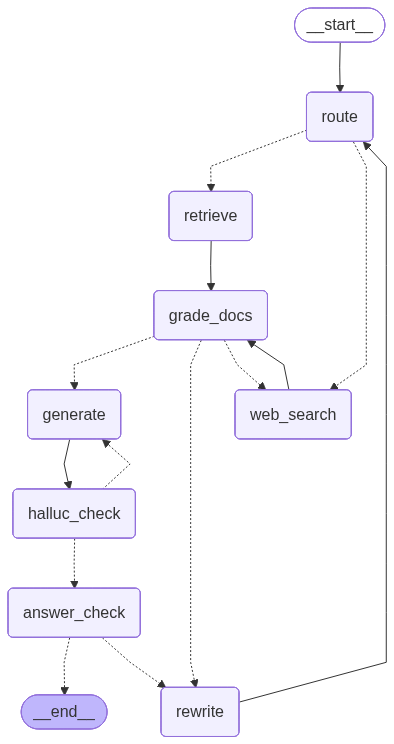

✅ Grafo visualizado


In [29]:
try:
    from IPython.display import Image, display
    img = graph.get_graph().draw_mermaid_png()
    display(Image(img))
    print("✅ Grafo visualizado")
except Exception as e:
    print(f"Visualización no disponible: {e}")
    print("Mermaid del grafo:")
    print(graph.get_graph().draw_mermaid())

### Función de Ejecución con Output Formateado

In [30]:
def run_agentic_rag(question: str) -> dict:
    """
    Ejecuta el pipeline Agentic RAG completo para una pregunta médica.

    Args:
        question: Pregunta médica en inglés (el dataset MedQuAD está en inglés)

    Returns:
        dict con la respuesta final y metadatos del pipeline
    """
    print("=" * 70)
    print(f"❓ PREGUNTA: {question}")
    print("=" * 70)

    initial_state: RAGState = {
        "question":          question,
        "datasource":        "",
        "documents":         [],
        "generation":        "",
        "graded_docs":       [],
        "web_search_needed": False,
        "hallucination_ok":  False,
        "answer_useful":     False,
        "iterations":        0,
    }

    final_state = graph.invoke(initial_state)

    print("\n" + "=" * 70)
    print("📋 RESPUESTA FINAL:")
    print("=" * 70)
    print(final_state["generation"])
    print("\n" + "-" * 70)
    print(f"📊 Metadatos del Pipeline:")
    print(f"   • Fuente inicial:       {final_state['datasource']}")
    print(f"   • Docs recuperados:     {len(final_state['documents'])}")
    print(f"   • Docs relevantes:      {len(final_state['graded_docs'])}")
    print(f"   • Sin alucinaciones:    {final_state['hallucination_ok']}")
    print(f"   • Respuesta útil:       {final_state['answer_useful']}")
    print(f"   • Iteraciones totales:  {final_state['iterations']}")
    print("=" * 70)

    return final_state

### Test 1: Pregunta médica directa (debería ir al VectorStore)

In [31]:
result1 = run_agentic_rag(
    "What are the symptoms and treatment options for Type 2 diabetes?"
)

❓ PREGUNTA: What are the symptoms and treatment options for Type 2 diabetes?

🔀 [ROUTER] Analizando: 'What are the symptoms and treatment options for Type 2 diabe...'
   → Fuente seleccionada: vectorstore

🔍 [RETRIEVE] Buscando en VectorStore...
   → 4 documentos recuperados
   [1] Diabetes Type 1: Q: What is (are) Diabetes Type 1 ?

A: Diabetes means your blood glucose, or blo...
   [2] Diabetes: Q: What is (are) Diabetes ?

A: Diabetes is a disease in which your blood glucos...
   [3] Diabetes mellitus type 1: Q: What is (are) Diabetes mellitus type 1 ?

A: Diabetes mellitus type 1 (DM1) i...
   [4] Gastroparesis: Q: What are the treatments for Gastroparesis ?

A: An elevated blood glucose lev...

⚖️  [GRADER] Evaluando 4 documentos...
   [❌] Doc 1: DESCARTADO
   [❌] Doc 2: DESCARTADO
   [❌] Doc 3: DESCARTADO
   [❌] Doc 4: DESCARTADO
   → 0 docs relevantes, web_search_needed=True

✏️  [REWRITER] Reformulando query...
   Original: 'What are the symptoms and treatment options for Type 

### Test 2: Pregunta sobre medicamento (VectorStore)

In [32]:
result2 = run_agentic_rag(
    "What are the side effects of metformin and how should it be taken?"
)

❓ PREGUNTA: What are the side effects of metformin and how should it be taken?

🔀 [ROUTER] Analizando: 'What are the side effects of metformin and how should it be ...'
   → Fuente seleccionada: vectorstore

🔍 [RETRIEVE] Buscando en VectorStore...
   → 4 documentos recuperados
   [1] Prescription Drug Abuse: Q: What is (are) Prescription Drug Abuse ?

A: If you take a medicine in a way t...
   [2] Hypoglycemia: Q: What causes Hypoglycemia ?

A: Diabetes Medications
                
Hypoglyc...
   [3] Medium-chain acyl-coenzyme A dehydrogenase deficiency: Q: What are the symptoms of Medium-chain acyl-coenzyme A dehydrogenase deficienc...
   [4] Cocaine: Q: Do you have information about Cocaine

A: Summary : Cocaine is a white powder...

⚖️  [GRADER] Evaluando 4 documentos...
   [❌] Doc 1: DESCARTADO
   [❌] Doc 2: DESCARTADO
   [❌] Doc 3: DESCARTADO
   [❌] Doc 4: DESCARTADO
   → 0 docs relevantes, web_search_needed=True

✏️  [REWRITER] Reformulando query...
   Original: 'What are the sid

### Test 3: Pregunta reciente/off-topic (debería ir a Web Search)

In [33]:
result3 = run_agentic_rag(
    "What are the latest 2024 WHO guidelines for COVID-19 treatment?"
)

❓ PREGUNTA: What are the latest 2024 WHO guidelines for COVID-19 treatment?

🔀 [ROUTER] Analizando: 'What are the latest 2024 WHO guidelines for COVID-19 treatme...'
   → Fuente seleccionada: web_search

🌐 [WEB SEARCH] Buscando: 'What are the latest 2024 WHO guidelines for COVID-19 treatme...'
   → 3 resultados web obtenidos (simulados)

⚖️  [GRADER] Evaluando 3 documentos...
   [✅] Doc 1: RELEVANTE
   [✅] Doc 2: RELEVANTE
   [✅] Doc 3: RELEVANTE
   → 3 docs relevantes, web_search_needed=False

📝 [GENERATE] Generando respuesta...
   → Respuesta generada (1445 chars)

🛡️  [HALLUCINATION CHECK] Verificando...
   → Grounded: no (hallucination_ok=False, iter=1)

📝 [GENERATE] Generando respuesta...
   → Respuesta generada (1436 chars)

🛡️  [HALLUCINATION CHECK] Verificando...
   → Grounded: no (hallucination_ok=False, iter=2)

📝 [GENERATE] Generando respuesta...
   → Respuesta generada (1392 chars)

🛡️  [HALLUCINATION CHECK] Verificando...
   → Grounded: yes (hallucination_ok=True, iter=3)


### Test 4: Pregunta sobre enfermedad crónica

In [34]:
result4 = run_agentic_rag(
    "What causes hypertension and how can it be managed without medication?"
)

❓ PREGUNTA: What causes hypertension and how can it be managed without medication?

🔀 [ROUTER] Analizando: 'What causes hypertension and how can it be managed without m...'
   → Fuente seleccionada: vectorstore

🔍 [RETRIEVE] Buscando en VectorStore...
   → 4 documentos recuperados
   [1] Takayasu arteritis: Q: What are the treatments for Takayasu arteritis ?

A: How might Takayasu arter...
   [2] High Blood Pressure: Q: What are the treatments for High Blood Pressure ?

A: Today, many different t...
   [3] Addison Disease: Q: What is (are) Addison Disease ?

A: Your adrenal glands are just above your k...
   [4] Nephrotic Syndrome in Adults: Q: What are the treatments for Nephrotic Syndrome in Adults ?

A: Treating nephr...

⚖️  [GRADER] Evaluando 4 documentos...
   [❌] Doc 1: DESCARTADO
   [❌] Doc 2: DESCARTADO
   [❌] Doc 3: DESCARTADO
   [❌] Doc 4: DESCARTADO
   → 0 docs relevantes, web_search_needed=True

✏️  [REWRITER] Reformulando query...
   Original: 'What causes hypertension an

### Análisis del Dataset: Preguntas más frecuentes por categoría

Columnas disponibles: ['question', 'answer', 'source', 'focus_area']


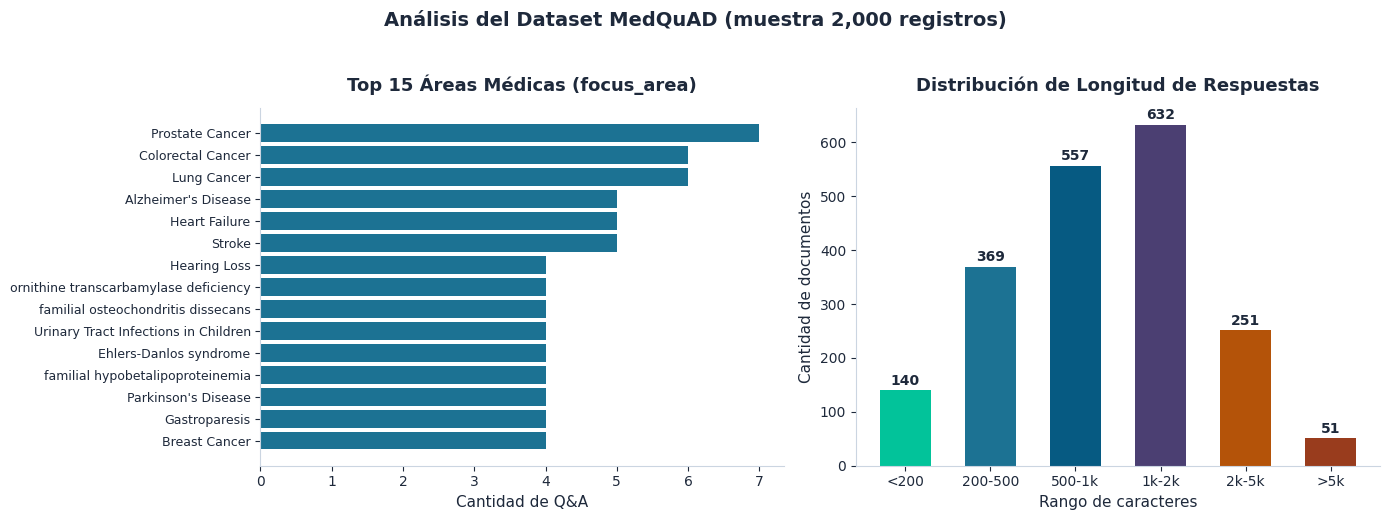

✅ Gráfico guardado en medquad_analysis.png

📊 Estadísticas del Dataset MedQuAD (muestra):
   Total registros:    2,000
   Áreas médicas:      1,557
   Long. media Q:      51 chars
   Long. media A:      1308 chars
   Long. min  A:       50 chars
   Long. max  A:       29,046 chars

📋 Top 10 áreas médicas más frecuentes:
focus_area
Prostate Cancer                          7
Colorectal Cancer                        6
Lung Cancer                              6
Alzheimer's Disease                      5
Heart Failure                            5
Stroke                                   5
Hearing Loss                             4
ornithine transcarbamylase deficiency    4
familial osteochondritis dissecans       4
Urinary Tract Infections in Children     4


In [35]:
import matplotlib.pyplot as plt
import matplotlib as mpl

%matplotlib inline

# ── Forzar estilo claro independiente del tema de Jupyter ─────
plt.rcParams.update({
    "figure.facecolor":  "white",
    "axes.facecolor":    "white",
    "axes.labelcolor":   "#1E293B",
    "axes.titlecolor":   "#1E293B",
    "xtick.color":       "#1E293B",
    "ytick.color":       "#1E293B",
    "text.color":        "#1E293B",
    "grid.color":        "#E2ECF4",
    "figure.edgecolor":  "white",
})

print(f"Columnas disponibles: {df_sample.columns.tolist()}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.patch.set_facecolor("white")

# ── Gráfico 1: Top 15 áreas médicas ──────────────────────────
focus_counts = df_sample["focus_area"].value_counts().head(15)
axes[0].barh(focus_counts.index, focus_counts.values, color="#1C7293")
axes[0].set_facecolor("white")
axes[0].set_title("Top 15 Áreas Médicas (focus_area)",
                  fontsize=13, fontweight="bold", color="#1E293B", pad=12)
axes[0].set_xlabel("Cantidad de Q&A", color="#1E293B", fontsize=11)
axes[0].invert_yaxis()
axes[0].tick_params(axis="y", labelsize=9,  colors="#1E293B")
axes[0].tick_params(axis="x", labelsize=10, colors="#1E293B")
for spine in ["top", "right"]:
    axes[0].spines[spine].set_visible(False)
for spine in ["left", "bottom"]:
    axes[0].spines[spine].set_color("#CBD5E1")

# ── Gráfico 2: Distribución de longitud de respuestas ─────────
lengths = df_sample["answer"].str.len()
bins    = [0, 200, 500, 1000, 2000, 5000, lengths.max() + 1]
labels  = ["<200", "200-500", "500-1k", "1k-2k", "2k-5k", ">5k"]
df_sample["answer_len_cat"] = pd.cut(lengths, bins=bins, labels=labels, right=False)

len_counts = df_sample["answer_len_cat"].value_counts().sort_index()
colors = ["#02C39A", "#1C7293", "#065A82", "#4B3F72", "#B45309", "#993C1D"]
bars = axes[1].bar(len_counts.index, len_counts.values,
                   color=colors[:len(len_counts)], width=0.6)
axes[1].set_facecolor("white")
axes[1].set_title("Distribución de Longitud de Respuestas",
                  fontsize=13, fontweight="bold", color="#1E293B", pad=12)
axes[1].set_xlabel("Rango de caracteres", color="#1E293B", fontsize=11)
axes[1].set_ylabel("Cantidad de documentos", color="#1E293B", fontsize=11)
axes[1].tick_params(axis="both", colors="#1E293B")
for spine in ["top", "right"]:
    axes[1].spines[spine].set_visible(False)
for spine in ["left", "bottom"]:
    axes[1].spines[spine].set_color("#CBD5E1")

# Etiquetas encima de las barras
for bar in bars:
    h = bar.get_height()
    axes[1].text(bar.get_x() + bar.get_width() / 2., h + 5,
                 str(int(h)), ha="center", va="bottom",
                 fontsize=10, fontweight="bold", color="#1E293B")

plt.suptitle("Análisis del Dataset MedQuAD (muestra 2,000 registros)",
             fontsize=14, fontweight="bold", color="#1E293B", y=1.03)
plt.tight_layout()
plt.savefig("medquad_analysis.png", dpi=120, bbox_inches="tight",
            facecolor="white")
plt.show()
print("✅ Gráfico guardado en medquad_analysis.png")

# ── Estadísticas ──────────────────────────────────────────────
print(f"\n📊 Estadísticas del Dataset MedQuAD (muestra):")
print(f"   Total registros:    {len(df_sample):,}")
print(f"   Áreas médicas:      {df_sample['focus_area'].nunique():,}")
print(f"   Long. media Q:      {df_sample['question'].str.len().mean():.0f} chars")
print(f"   Long. media A:      {df_sample['answer'].str.len().mean():.0f} chars")
print(f"   Long. min  A:       {df_sample['answer'].str.len().min():,} chars")
print(f"   Long. max  A:       {df_sample['answer'].str.len().max():,} chars")
print(f"\n📋 Top 10 áreas médicas más frecuentes:")
print(df_sample["focus_area"].value_counts().head(10).to_string())

### Benchmark: Comparar Preguntas del Dataset Real

In [36]:
# Tomar 5 preguntas reales del dataset para testear el pipeline
test_questions = df_sample["question"].sample(5, random_state=99).tolist()

print("🧪 BENCHMARK CON PREGUNTAS REALES DE MedQuAD\n")
print("=" * 70)

benchmark_results = []
for i, q in enumerate(test_questions, 1):
    print(f"\n[{i}/5] Procesando...")
    state = run_agentic_rag(q)
    benchmark_results.append({
        "question":       q,
        "datasource":     state["datasource"],
        "docs_retrieved": len(state["documents"]),
        "docs_relevant":  len(state["graded_docs"]),
        "no_hallucination": state["hallucination_ok"],
        "answer_useful":  state["answer_useful"],
        "iterations":     state["iterations"],
        "answer_length":  len(state["generation"]),
    })

# Resumen del benchmark
bench_df = pd.DataFrame(benchmark_results)
print("\n\n📊 RESUMEN DEL BENCHMARK:")
print(bench_df[[
    "datasource", "docs_retrieved", "docs_relevant",
    "no_hallucination", "answer_useful", "iterations"
]].to_string(index=False))
print(f"\n✅ Sin alucinaciones: {bench_df['no_hallucination'].sum()}/5")
print(f"✅ Respuestas útiles: {bench_df['answer_useful'].sum()}/5")
print(f"📈 Promedio docs relevantes: {bench_df['docs_relevant'].mean():.1f}")
print(f"🔁 Promedio iteraciones: {bench_df['iterations'].mean():.1f}")

🧪 BENCHMARK CON PREGUNTAS REALES DE MedQuAD


[1/5] Procesando...
❓ PREGUNTA: What is (are) Nephrogenic diabetes insipidus ?

🔀 [ROUTER] Analizando: 'What is (are) Nephrogenic diabetes insipidus ?...'
   → Fuente seleccionada: vectorstore

🔍 [RETRIEVE] Buscando en VectorStore...
   → 4 documentos recuperados
   [1] Nephrogenic diabetes insipidus: Q: What is (are) Nephrogenic diabetes insipidus ?

A: Nephrogenic diabetes insip...
   [2] nephrogenic diabetes insipidus: Q: What is (are) nephrogenic diabetes insipidus ?

A: Nephrogenic diabetes insip...
   [3] nephronophthisis: Q: What is (are) nephronophthisis ?

A: Nephronophthisis is a disorder that affe...
   [4] Lupus nephritis: Q: What is (are) Lupus nephritis ?

A: Lupus nephritis is a kidney disorder that...

⚖️  [GRADER] Evaluando 4 documentos...
   [✅] Doc 1: RELEVANTE
   [✅] Doc 2: RELEVANTE
   [❌] Doc 3: DESCARTADO
   [❌] Doc 4: DESCARTADO
   → 2 docs relevantes, web_search_needed=False

📝 [GENERATE] Generando respuesta...
   →

### Extensión Opcional: Ejecutar con LangSmith Tracing

In [37]:
# ============================================================
# Observabilidad con LangSmith (opcional)
# Requiere: pip install langsmith
# ============================================================

# os.environ["LANGCHAIN_TRACING_V2"] = "true"
# os.environ["LANGCHAIN_API_KEY"]     = "tu_langsmith_api_key"
# os.environ["LANGCHAIN_PROJECT"]     = "agentic-rag-medquad"

# Con estas variables, todos los runs del grafo quedan
# registrados en https://smith.langchain.com con:
# - Trazas completas de cada nodo
# - Tokens consumidos por paso
# - Latencias y retry loops visualizados
# - Replay de runs para debugging

print("💡 Para habilitar LangSmith tracing, descomenta las líneas anteriores.")
print("   Ver trazas en: https://smith.langchain.com")

💡 Para habilitar LangSmith tracing, descomenta las líneas anteriores.
   Ver trazas en: https://smith.langchain.com
